# CR5 — Semaine 5 : Évaluation
## FER2013 — Reconnaissance des Émotions Faciales

**Objectifs de la semaine :**
- Évaluation complète sur l'ensemble de test (7 178 images)
- Matrices de confusion pour les 3 modèles entraînés (S4)
- Métriques détaillées : accuracy, précision, rappel, F1
- Tests sur nouvelles données avec visualisations
- Analyse critique des performances

**Modèles évalués :**

| Modèle | Paramètres | Val. Acc. (S4) | Statut |
|---|---|---|---|
| Baseline CNN | ~390K | 62.47% | Référence |
| **Deep CNN** | **~1.5M** | **68.32%** | **Meilleur** |
| EfficientNet-B0 | ~4M | 66.94% | Surapprentissage |

---

## 0. Configuration & Imports

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────
ROOT    = Path('..').resolve()
SRC_DIR = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))

from dataset import FERDataset
from model import BaselineCNN, DeepCNN, TransferModel
from transforms import GaussianDenoise, CLAHE

# ── Constants ────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
RESULTS_DIR = ROOT / 'results'
CKPT_DIR    = ROOT / 'checkpoints'
DATA_ROOT   = str(ROOT / 'data' / 'fer2013' / 'archive')

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
sns.set_style('whitegrid')

print(f'Device  : {DEVICE}')
print(f'Projet  : {ROOT.name}')
print(f'Classes : {CLASS_NAMES}')

Device  : cuda
Projet  : fer_emotions
Classes : ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## 1. Chargement des Modèles

Les trois modèles entraînés lors de la Semaine 4 sont rechargés depuis leurs fichiers de checkpoint (meilleur epoch selon la validation).

In [2]:
def load_model(model, ckpt_path, device):
    """Load a model from a checkpoint file."""
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    return model

baseline = load_model(
    BaselineCNN(num_classes=7),
    CKPT_DIR / 'baseline_cnn_best.pth',
    DEVICE
)
deep = load_model(
    DeepCNN(num_classes=7),
    CKPT_DIR / 'deep_cnn_best.pth',
    DEVICE
)
effnet = load_model(
    TransferModel(backbone='efficientnet_b0', num_classes=7, pretrained=False),
    CKPT_DIR / 'efficientnet_b0_best.pth',
    DEVICE
)

MODELS = {
    'Baseline CNN'    : baseline,
    'Deep CNN'        : deep,
    'EfficientNet-B0' : effnet,
}

print('Modeles charges avec succes :')
for name, m in MODELS.items():
    params = sum(p.numel() for p in m.parameters())
    print(f'  {name:<20}  {params:>10,} params')

Modeles charges avec succes :
  Baseline CNN             390,119 params
  Deep CNN               1,330,599 params
  EfficientNet-B0        4,015,939 params


## 2. Données de Test

Le jeu de test FER2013 contient **7 178 images** (28 × 28 pixels, niveaux de gris), organisées en 7 classes. Le même pipeline de prétraitement que lors de l'entraînement est appliqué :

1. Débruitage gaussien (noyau 3×3, σ=0.8)
2. Amélioration de contraste CLAHE (clipLimit=2.0, grille 4×4)
3. Normalisation (μ=0.563, σ=0.2627, statistiques calculées après CLAHE)

In [3]:
# Val/test transform (no data augmentation)
val_tfm = transforms.Compose([
    GaussianDenoise(),
    CLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.563], std=[0.2627]),
])

# Dataset with transforms (for inference)
test_ds = FERDataset(DATA_ROOT, split='test', transform=val_tfm)
test_loader = DataLoader(
    test_ds, batch_size=256, shuffle=False,
    num_workers=0, pin_memory=(DEVICE.type == 'cuda')
)

# Raw dataset without transforms (for visualization)
raw_test_ds = FERDataset(DATA_ROOT, split='test', transform=None)

print(test_ds)
print(f'\nNombre de batches : {len(test_loader)}')

FERDataset(split='test', format='folder', total=7178)
  Angry     : 958
  Disgust   : 111
  Fear      : 1024
  Happy     : 1774
  Sad       : 1247
  Surprise  : 831
  Neutral   : 1233

Nombre de batches : 29


## 3. Inférence sur l'Ensemble de Test

Chaque modèle effectue une passe complète sur les 7 178 images de test. Les logits sont convertis en probabilités via softmax, et la classe prédite est celle de probabilité maximale.

In [4]:
@torch.no_grad()
def run_inference(model, loader, device):
    """Run model on all batches; return arrays of predictions, labels, probabilities."""
    all_preds, all_labels, all_probs = [], [], []
    model.eval()
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    return (
        np.concatenate(all_preds),
        np.concatenate(all_labels),
        np.concatenate(all_probs)
    )

results = {}
for name, model in MODELS.items():
    print(f'Evaluation {name}...', end='  ')
    preds, labels, probs = run_inference(model, test_loader, DEVICE)
    results[name] = {'preds': preds, 'labels': labels, 'probs': probs}
    acc = accuracy_score(labels, preds)
    print(f'Accuracy : {acc*100:.2f}%')

Evaluation Baseline CNN...  Accuracy : 56.09%
Evaluation Deep CNN...  Accuracy : 65.19%
Evaluation EfficientNet-B0...  Accuracy : 61.67%


## 4. Métriques Globales

Les métriques suivantes sont calculées pour chaque modèle :

- **Accuracy** : proportion globale de prédictions correctes
- **Précision (macro)** : moyenne non pondérée des précisions par classe
- **Rappel (macro)** : moyenne non pondérée des rappels par classe
- **F1 (macro)** : harmonie précision/rappel, non pondérée (pénalise les classes rares sous-performantes)
- **F1 (pondéré)** : F1 pondéré par le support réel de chaque classe

In [5]:
# ── Compute all metrics ───────────────────────────────────────────────────
metrics_data = []
for name, res in results.items():
    preds, labels = res['preds'], res['labels']
    metrics_data.append({
        'Modele'              : name,
        'Accuracy'            : accuracy_score(labels, preds),
        'Precision (macro)'   : precision_score(labels, preds, average='macro',    zero_division=0),
        'Rappel (macro)'      : recall_score(   labels, preds, average='macro',    zero_division=0),
        'F1 (macro)'          : f1_score(       labels, preds, average='macro',    zero_division=0),
        'F1 (pondere)'        : f1_score(       labels, preds, average='weighted', zero_division=0),
    })

metrics_raw = pd.DataFrame(metrics_data).set_index('Modele')
metrics_pct = metrics_raw.map(lambda x: f'{x*100:.2f}%')

print('=== Metriques globales sur le jeu de test ===')
display(metrics_pct)

# Save CSV
metrics_raw.to_csv(RESULTS_DIR / 'cr5_metrics.csv')
print('\nSauvegarde : results/cr5_metrics.csv')

=== Metriques globales sur le jeu de test ===


,Accuracy,Precision (macro),Rappel (macro),F1 (macro),F1 (pondere)
Modele,,,,,
Baseline CNN,56.09%,53.75%,57.12%,51.89%,56.84%
Deep CNN,65.19%,61.20%,64.62%,62.35%,65.07%
EfficientNet-B0,61.67%,61.21%,60.11%,60.40%,61.48%



Sauvegarde : results/cr5_metrics.csv


In [6]:
# Detailed classification report for best model (Deep CNN)
print('=== Rapport de Classification — Deep CNN ===')
print(classification_report(
    results['Deep CNN']['labels'],
    results['Deep CNN']['preds'],
    target_names=CLASS_NAMES,
    zero_division=0
))

=== Rapport de Classification — Deep CNN ===
              precision    recall  f1-score   support

       Angry       0.57      0.58      0.58       958
     Disgust       0.44      0.72      0.54       111
        Fear       0.51      0.43      0.47      1024
       Happy       0.85      0.86      0.86      1774
         Sad       0.52      0.56      0.54      1247
    Surprise       0.79      0.78      0.79       831
     Neutral       0.61      0.59      0.60      1233

    accuracy                           0.65      7178
   macro avg       0.61      0.65      0.62      7178
weighted avg       0.65      0.65      0.65      7178



## 5. Matrices de Confusion

Les matrices de confusion **normalisées par ligne** (recall par classe) permettent de visualiser comment chaque classe est reconnue et quelles sont les confusions entre émotions.

- La diagonale principale = recall par classe
- Les cellules hors-diagonale = taux de confusion entre classes

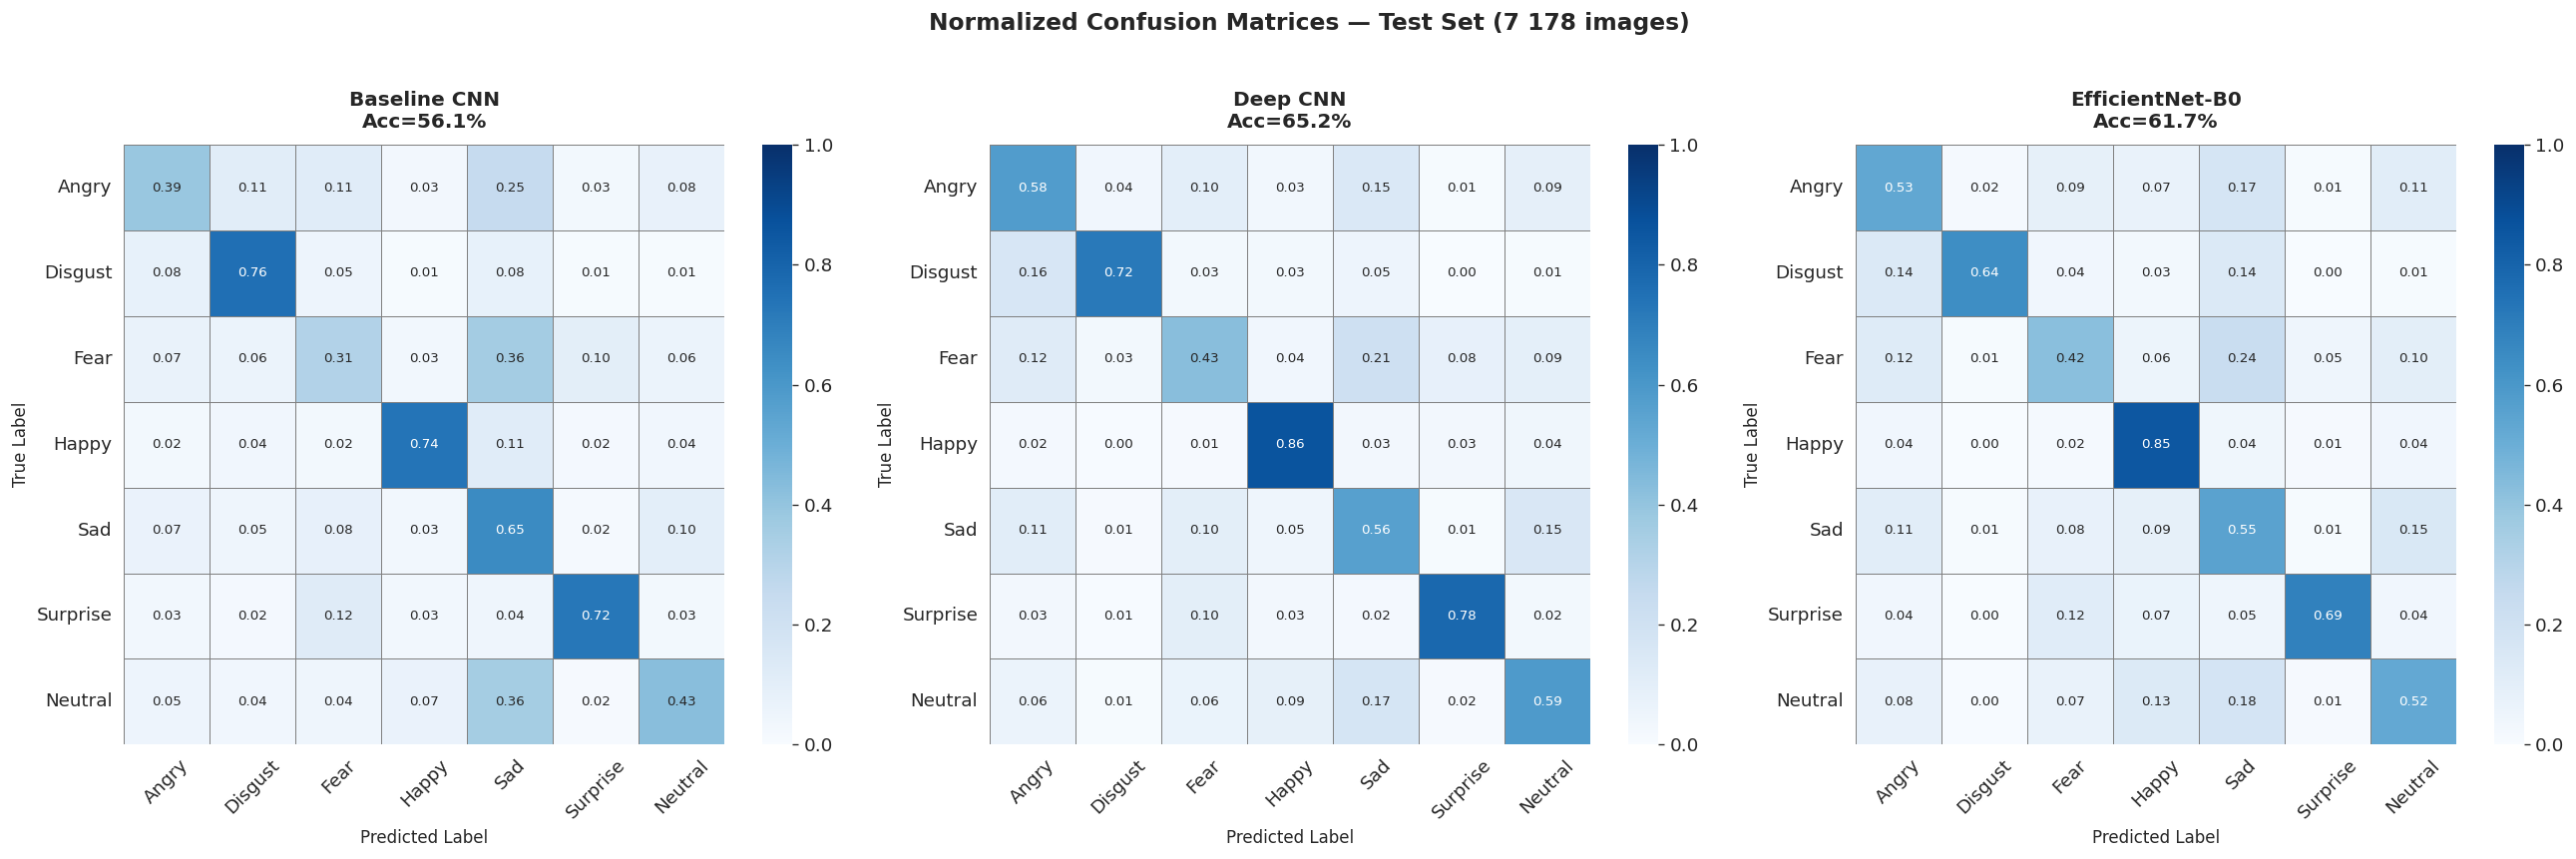

Sauvegarde : results/cr5_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['labels'], res['preds'], normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap='Blues', vmin=0, vmax=1,
        linewidths=0.5, linecolor='gray',
        annot_kws={'size': 8}
    )
    acc = accuracy_score(res['labels'], res['preds'])
    ax.set_title(f'{name}\nAcc={acc*100:.1f}%', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Normalized Confusion Matrices — Test Set (7 178 images)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_confusion_matrices.png')

## 6. Métriques par Classe

Les métriques **précision**, **rappel** et **F1-score** sont calculées individuellement pour chacune des 7 émotions, permettant d'identifier les classes difficiles à reconnaître.

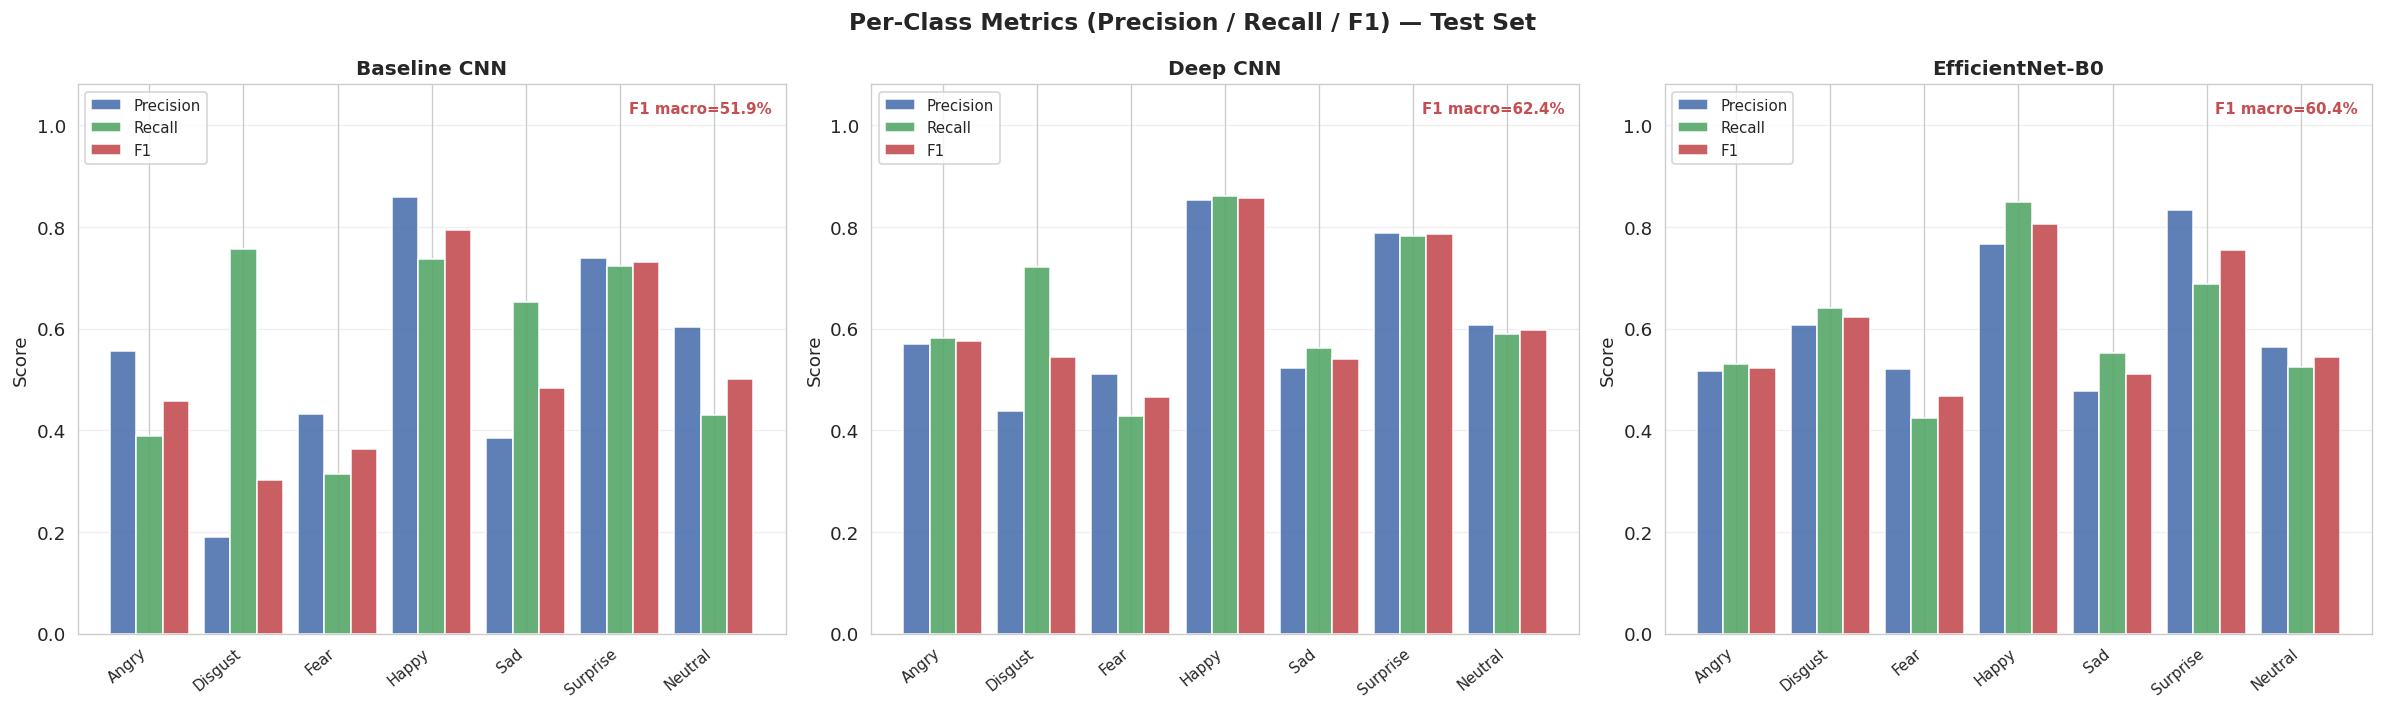

Sauvegarde : results/cr5_per_class_metrics.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res) in zip(axes, results.items()):
    preds, labels = res['preds'], res['labels']
    prec = precision_score(labels, preds, average=None, zero_division=0)
    rec  = recall_score(   labels, preds, average=None, zero_division=0)
    f1   = f1_score(       labels, preds, average=None, zero_division=0)

    x = np.arange(len(CLASS_NAMES))
    w = 0.28
    ax.bar(x - w, prec, w, label='Precision', color='#4C72B0', alpha=0.9)
    ax.bar(x,     rec,  w, label='Recall',    color='#55A868', alpha=0.9)
    ax.bar(x + w, f1,   w, label='F1',        color='#C44E52', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    ax.text(0.98, 0.97, f'F1 macro={mf1*100:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='#C44E52', fontweight='bold')

plt.suptitle('Per-Class Metrics (Precision / Recall / F1) — Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_per_class_metrics.png')

## 7. Tests sur Nouvelles Données

### 7.1 Tests depuis le Dataset FER2013

6 images par émotion sélectionnées aléatoirement dans l'ensemble de test FER2013.  
- **Vert** = prédiction correcte | **Rouge** = erreur | Pourcentage = confiance softmax

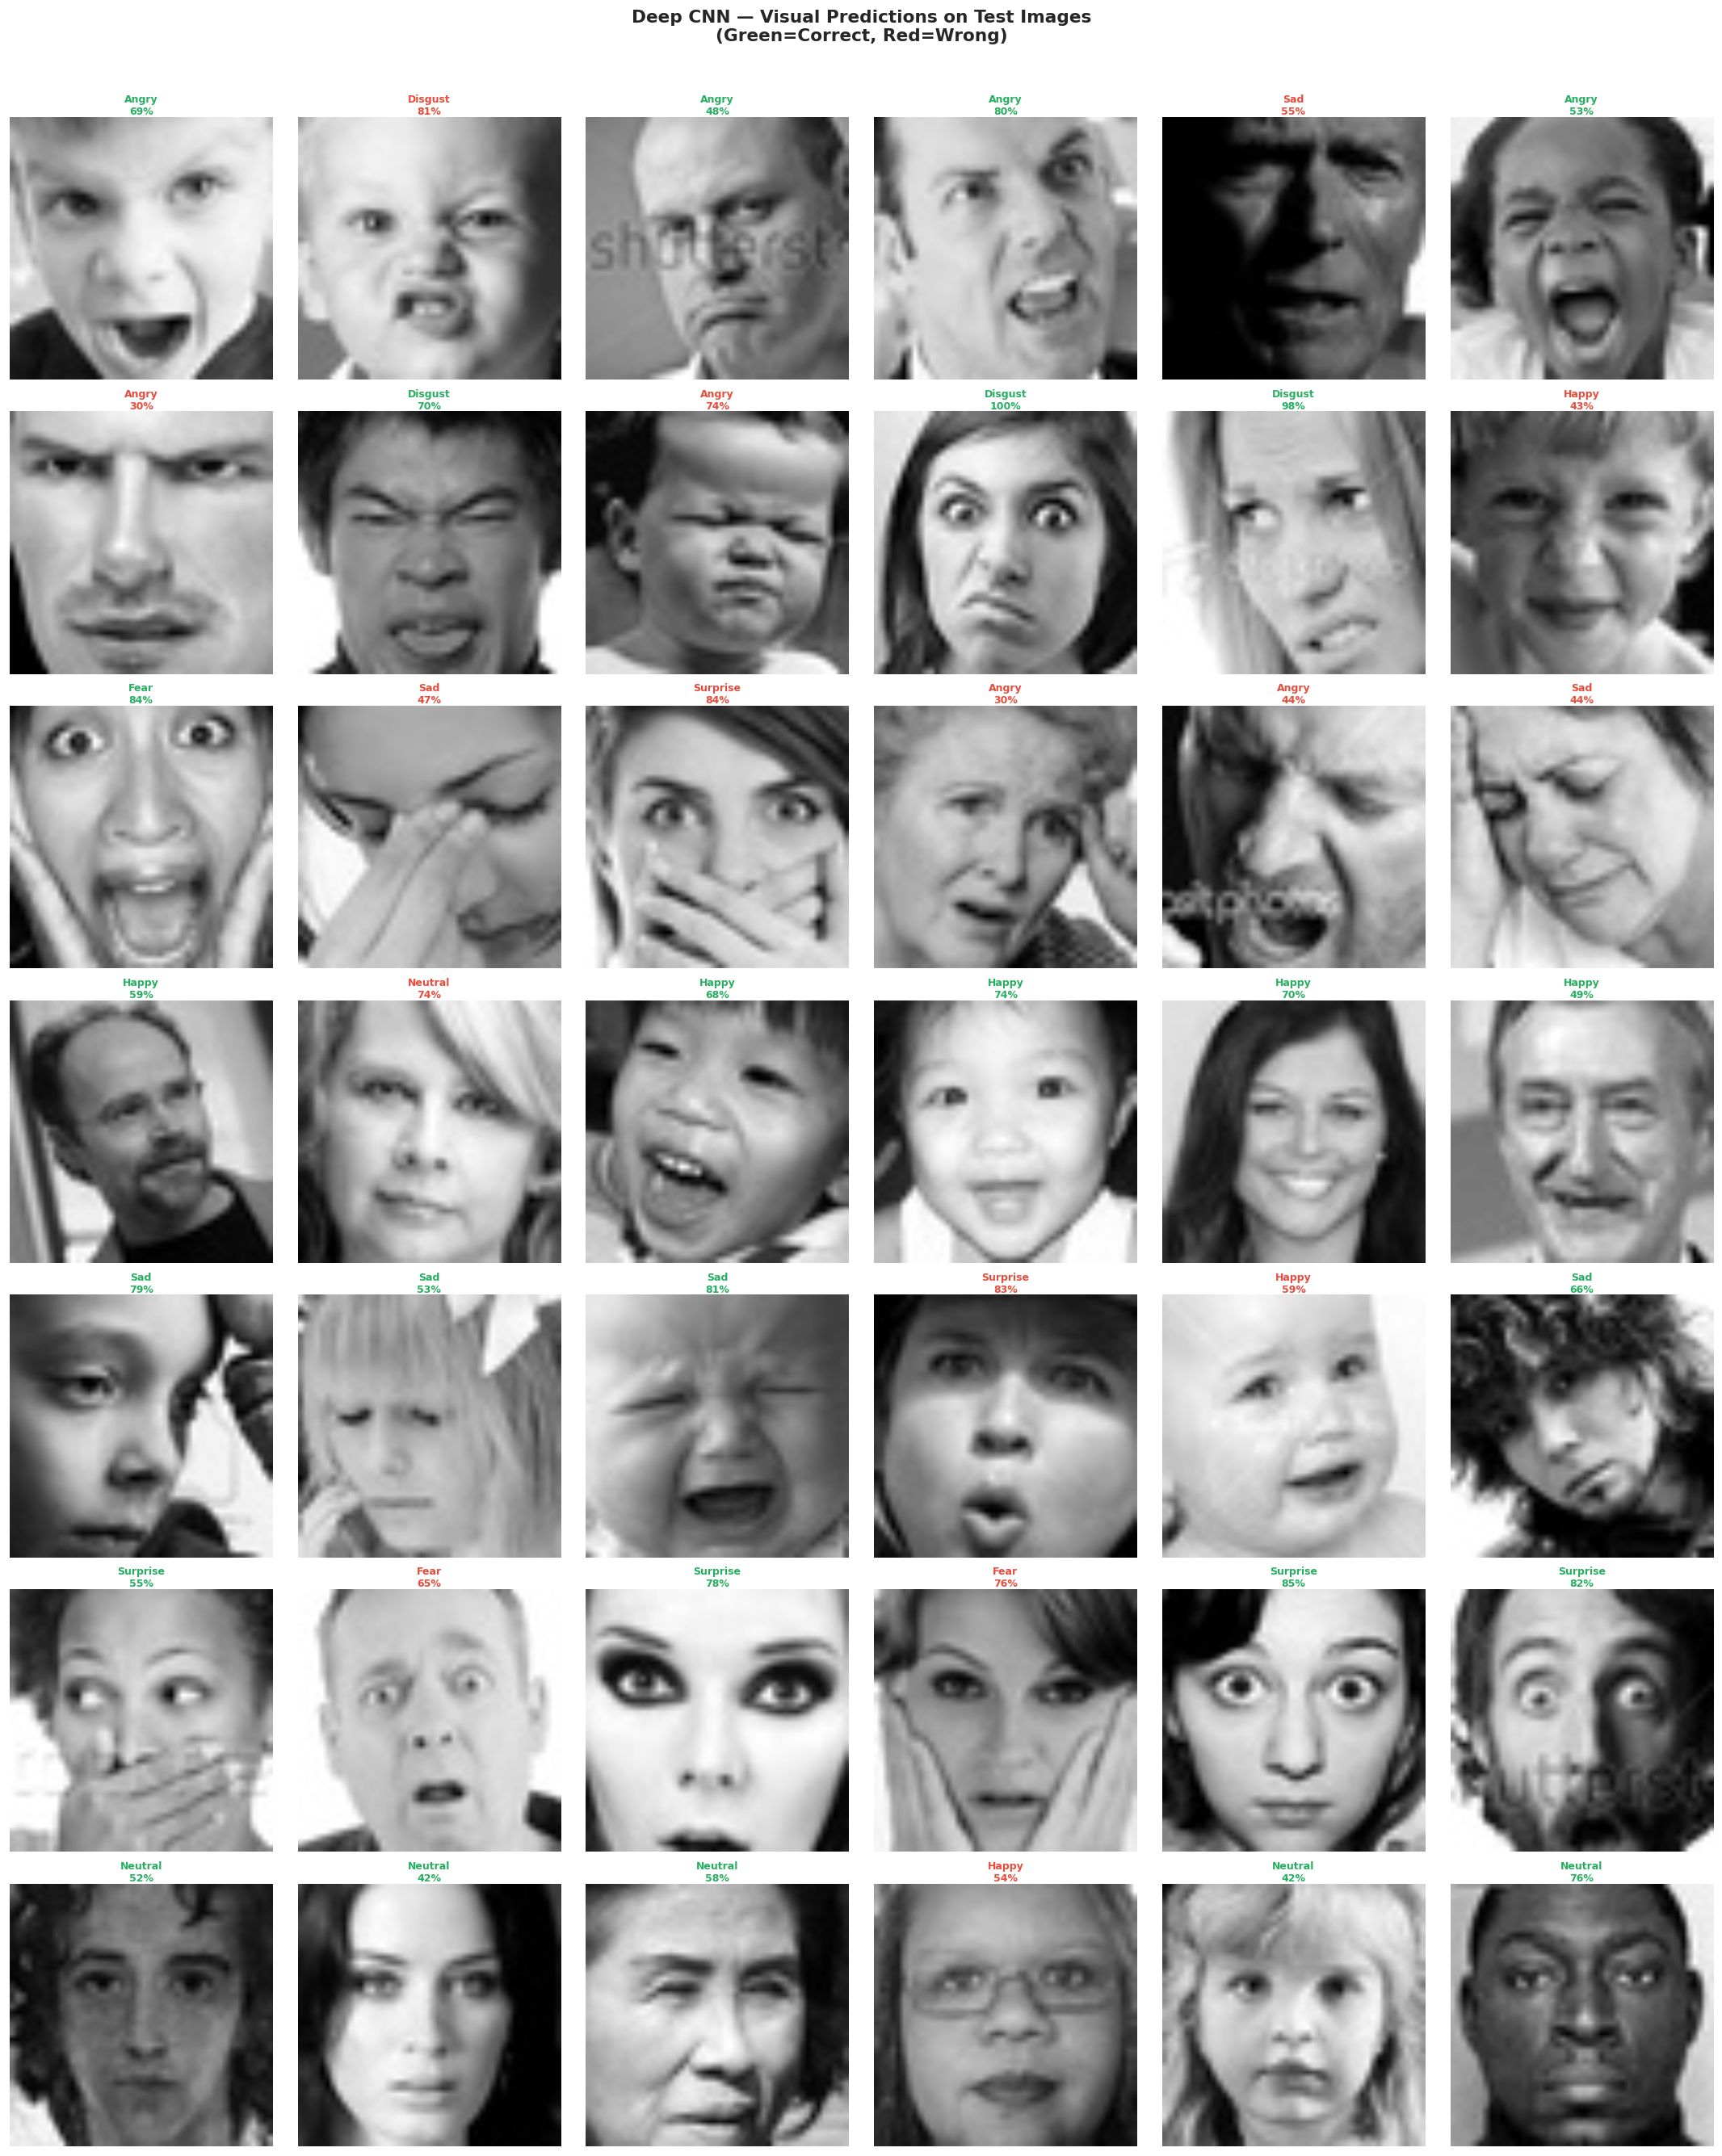

Sauvegarde : results/cr5_visual_predictions.png


In [9]:
np.random.seed(42)
N_COLS = 6
best_model = MODELS['Deep CNN']

fig, axes = plt.subplots(7, N_COLS, figsize=(18, 22))

for row, (class_idx, class_name) in enumerate(enumerate(CLASS_NAMES)):
    class_indices = [i for i, lbl in enumerate(raw_test_ds.labels) if lbl == class_idx]
    n_pick = min(N_COLS, len(class_indices))
    chosen = np.random.choice(class_indices, size=n_pick, replace=False)

    for col in range(N_COLS):
        ax = axes[row, col]
        if col >= n_pick:
            ax.axis('off')
            continue

        idx = chosen[col]
        img_pil, label = raw_test_ds[idx]
        img_tensor = val_tfm(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            probs = torch.softmax(best_model(img_tensor), dim=1).squeeze()
        pred = probs.argmax().item()
        conf = probs[pred].item()

        ax.imshow(np.array(img_pil), cmap='gray', interpolation='bilinear')
        color = '#27ae60' if pred == label else '#e74c3c'
        ax.set_title(f'{CLASS_NAMES[pred]}\n{conf*100:.0f}%',
                     fontsize=7.5, color=color, fontweight='bold', pad=2)
        ax.axis('off')

    axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold',
                             rotation=90, labelpad=10)

plt.suptitle('Deep CNN — Visual Predictions on Test Images\n(Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_visual_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_visual_predictions.png')

### 7.2 Prédictions Individuelles (FER2013) + Distribution de Probabilité

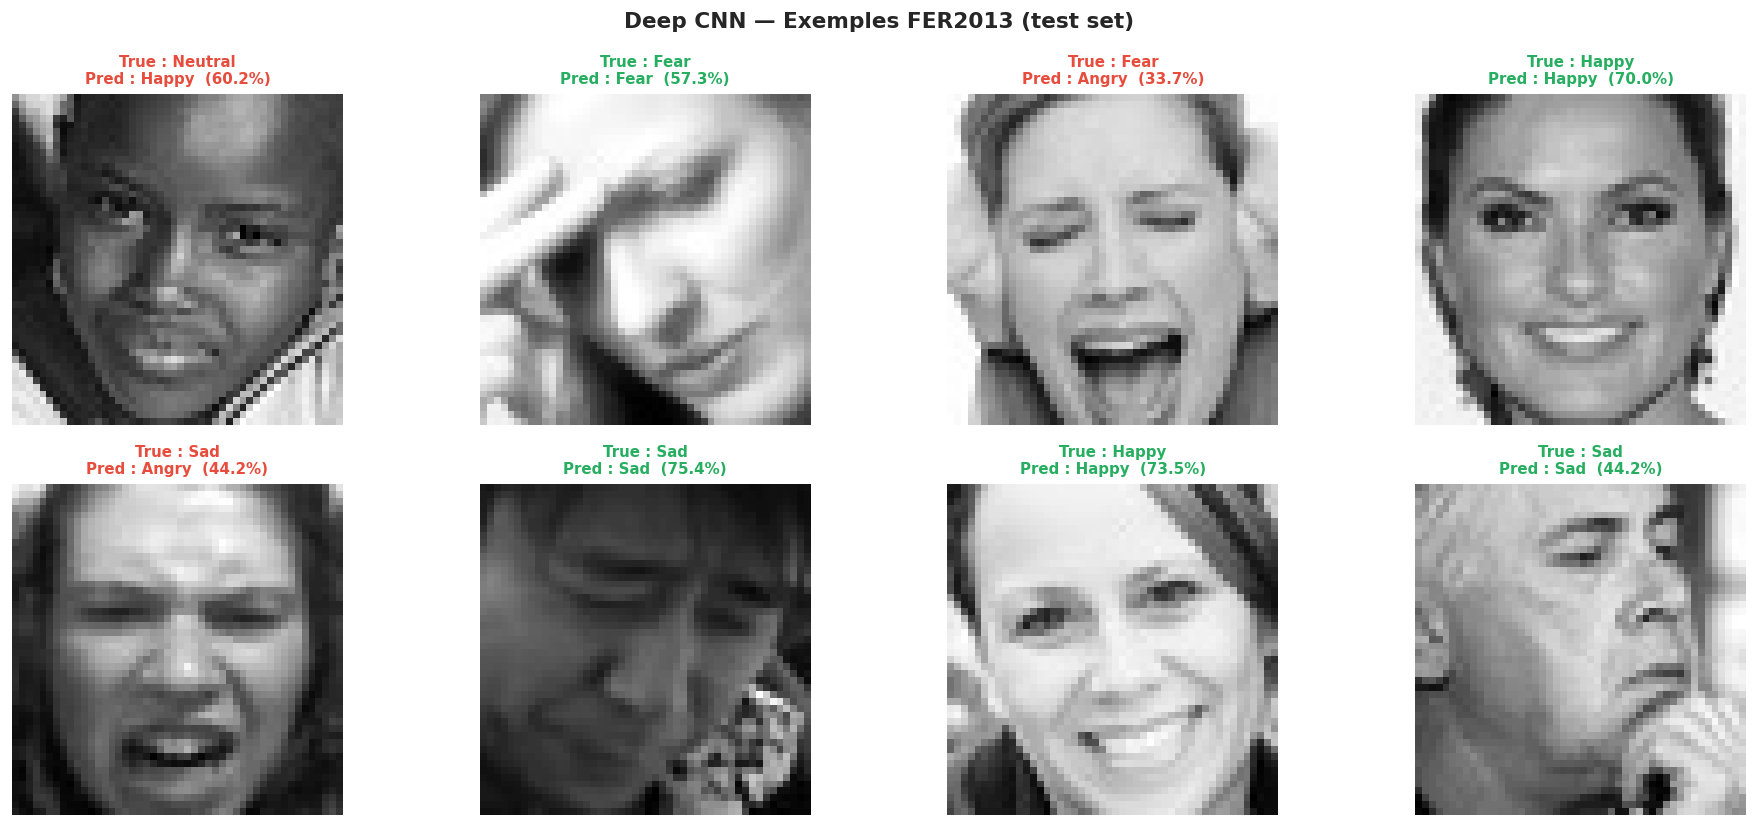

Sauvegarde : results/cr5_fer_predictions.png


In [10]:
def predict_image(img_pil, model, device, transform, class_names):
    """Return (pred_idx, pred_name, prob_array) for a single PIL image."""
    tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    pred_idx = int(probs.argmax())
    return pred_idx, class_names[pred_idx], probs

best_model = MODELS['Deep CNN']

np.random.seed(7)
fig, axes_arr = plt.subplots(2, 4, figsize=(16, 7))
axes_arr = axes_arr.flatten()

sample_indices = np.random.choice(len(raw_test_ds), size=8, replace=False)

for ax_idx, sample_idx in enumerate(sample_indices):
    img_pil, true_label = raw_test_ds[sample_idx]
    pred_idx, pred_name, probs = predict_image(img_pil, best_model, DEVICE, val_tfm, CLASS_NAMES)

    color = '#27ae60' if pred_idx == true_label else '#e74c3c'
    ax = axes_arr[ax_idx]
    ax.imshow(np.array(img_pil), cmap='gray')
    ax.set_title(
        f'True : {CLASS_NAMES[true_label]}\nPred : {pred_name}  ({probs[pred_idx]*100:.1f}%)',
        color=color, fontweight='bold', fontsize=9
    )
    ax.axis('off')

plt.suptitle('Deep CNN — Exemples FER2013 (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_fer_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_fer_predictions.png')

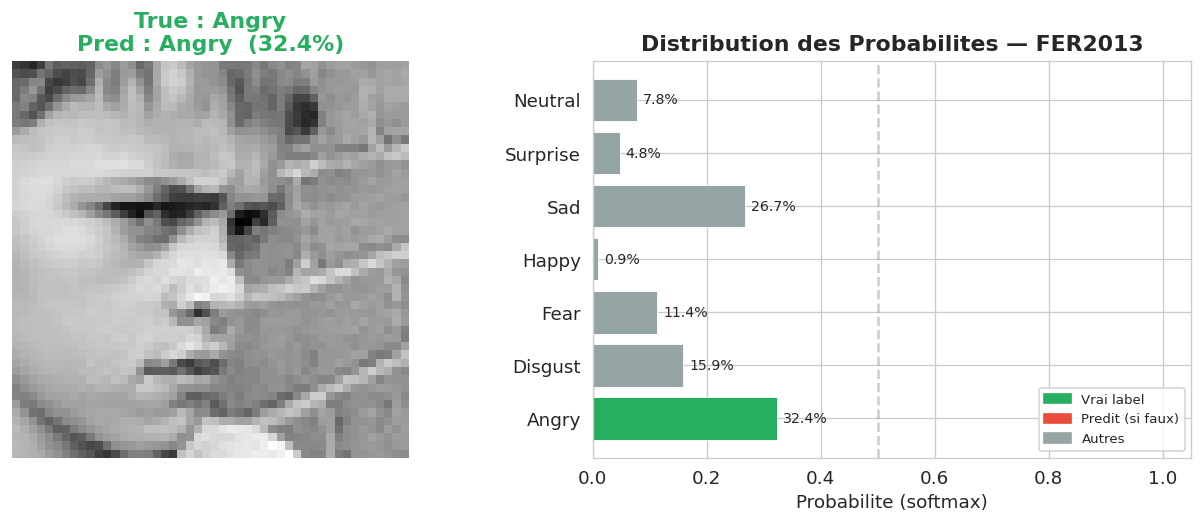

In [11]:
np.random.seed(42)
idx = np.random.choice(len(raw_test_ds))
img_pil, true_label = raw_test_ds[idx]
pred_idx, pred_name, probs = predict_image(img_pil, best_model, DEVICE, val_tfm, CLASS_NAMES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.imshow(np.array(img_pil), cmap='gray')
color = '#27ae60' if pred_idx == true_label else '#e74c3c'
ax1.set_title(
    f'True : {CLASS_NAMES[true_label]}\nPred : {pred_name}  ({probs[pred_idx]*100:.1f}%)',
    color=color, fontweight='bold'
)
ax1.axis('off')

bar_colors = ['#27ae60' if i == true_label else ('#e74c3c' if i == pred_idx else '#95a5a6')
              for i in range(7)]
bars = ax2.barh(CLASS_NAMES, probs, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.set_xlim(0, 1.05)
ax2.set_xlabel('Probabilite (softmax)')
ax2.set_title('Distribution des Probabilites — FER2013', fontweight='bold')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
for bar, prob in zip(bars, probs):
    ax2.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
             f'{prob*100:.1f}%', va='center', fontsize=8.5)

patches = [
    mpatches.Patch(color='#27ae60', label='Vrai label'),
    mpatches.Patch(color='#e74c3c', label='Predit (si faux)'),
    mpatches.Patch(color='#95a5a6', label='Autres'),
]
ax2.legend(handles=patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_prob_distribution_fer.png', dpi=120, bbox_inches='tight')
plt.show()

---

### 7.3 Tests sur Images Externes (hors FER2013)

Images téléchargées depuis Internet, placées dans `data/new_images/`.  
Ces images sont **totalement inconnues du modèle** — elles ne font partie ni du train ni du test set.

Le vrai label est déduit automatiquement du nom du fichier (ex: `happy_1.jpg` → Happy).

In [12]:
from PIL import Image as PILImage

NEW_IMAGES_DIR = ROOT / 'data' / 'new_images'
EXTENSIONS     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def load_external_image(img_path):
    """Load any image as grayscale 48x48 PIL Image."""
    return PILImage.open(img_path).convert('L').resize((48, 48), PILImage.LANCZOS)

def guess_label_from_filename(fname):
    """Infer true emotion from filename (e.g. happy_1.jpg -> 3). Returns None if unknown."""
    fname_lower = fname.lower()
    for idx, name in enumerate(CLASS_NAMES):
        if name.lower() in fname_lower:
            return idx
    return None

new_image_paths = sorted([p for p in NEW_IMAGES_DIR.iterdir()
                           if p.suffix.lower() in EXTENSIONS])

if not new_image_paths:
    print('Aucune image dans data/new_images/')
    print('Ajoutez des fichiers JPG/PNG et relancez cette cellule.')
else:
    print(f'{len(new_image_paths)} images trouvees dans data/new_images/ :')
    for p in new_image_paths:
        lbl = guess_label_from_filename(p.name)
        lbl_str = CLASS_NAMES[lbl] if lbl is not None else '(label inconnu)'
        print(f'  {p.name:35s}  -> label detecte : {lbl_str}')

7 images trouvees dans data/new_images/ :
  angry_1.jpg                          -> label detecte : Angry
  disgust_1.jpg                        -> label detecte : Disgust
  fear_1.jpg                           -> label detecte : Fear
  happy_1.jpg                          -> label detecte : Happy
  neutral_1.jpg                        -> label detecte : Neutral
  sad_1.jpg                            -> label detecte : Sad
  surprise_1.jpg                       -> label detecte : Surprise


Fichier                              Prediction     Confiance  Vrai label    Correct?
--------------------------------------------------------------------------------
angry_1.jpg                          Angry              59.2%  Angry         OK
disgust_1.jpg                        Happy              41.8%  Disgust       ERREUR
fear_1.jpg                           Surprise           44.5%  Fear          ERREUR
happy_1.jpg                          Happy              33.7%  Happy         OK
neutral_1.jpg                        Neutral            60.5%  Neutral       OK
sad_1.jpg                            Fear               47.6%  Sad           ERREUR
surprise_1.jpg                       Surprise           62.0%  Surprise      OK


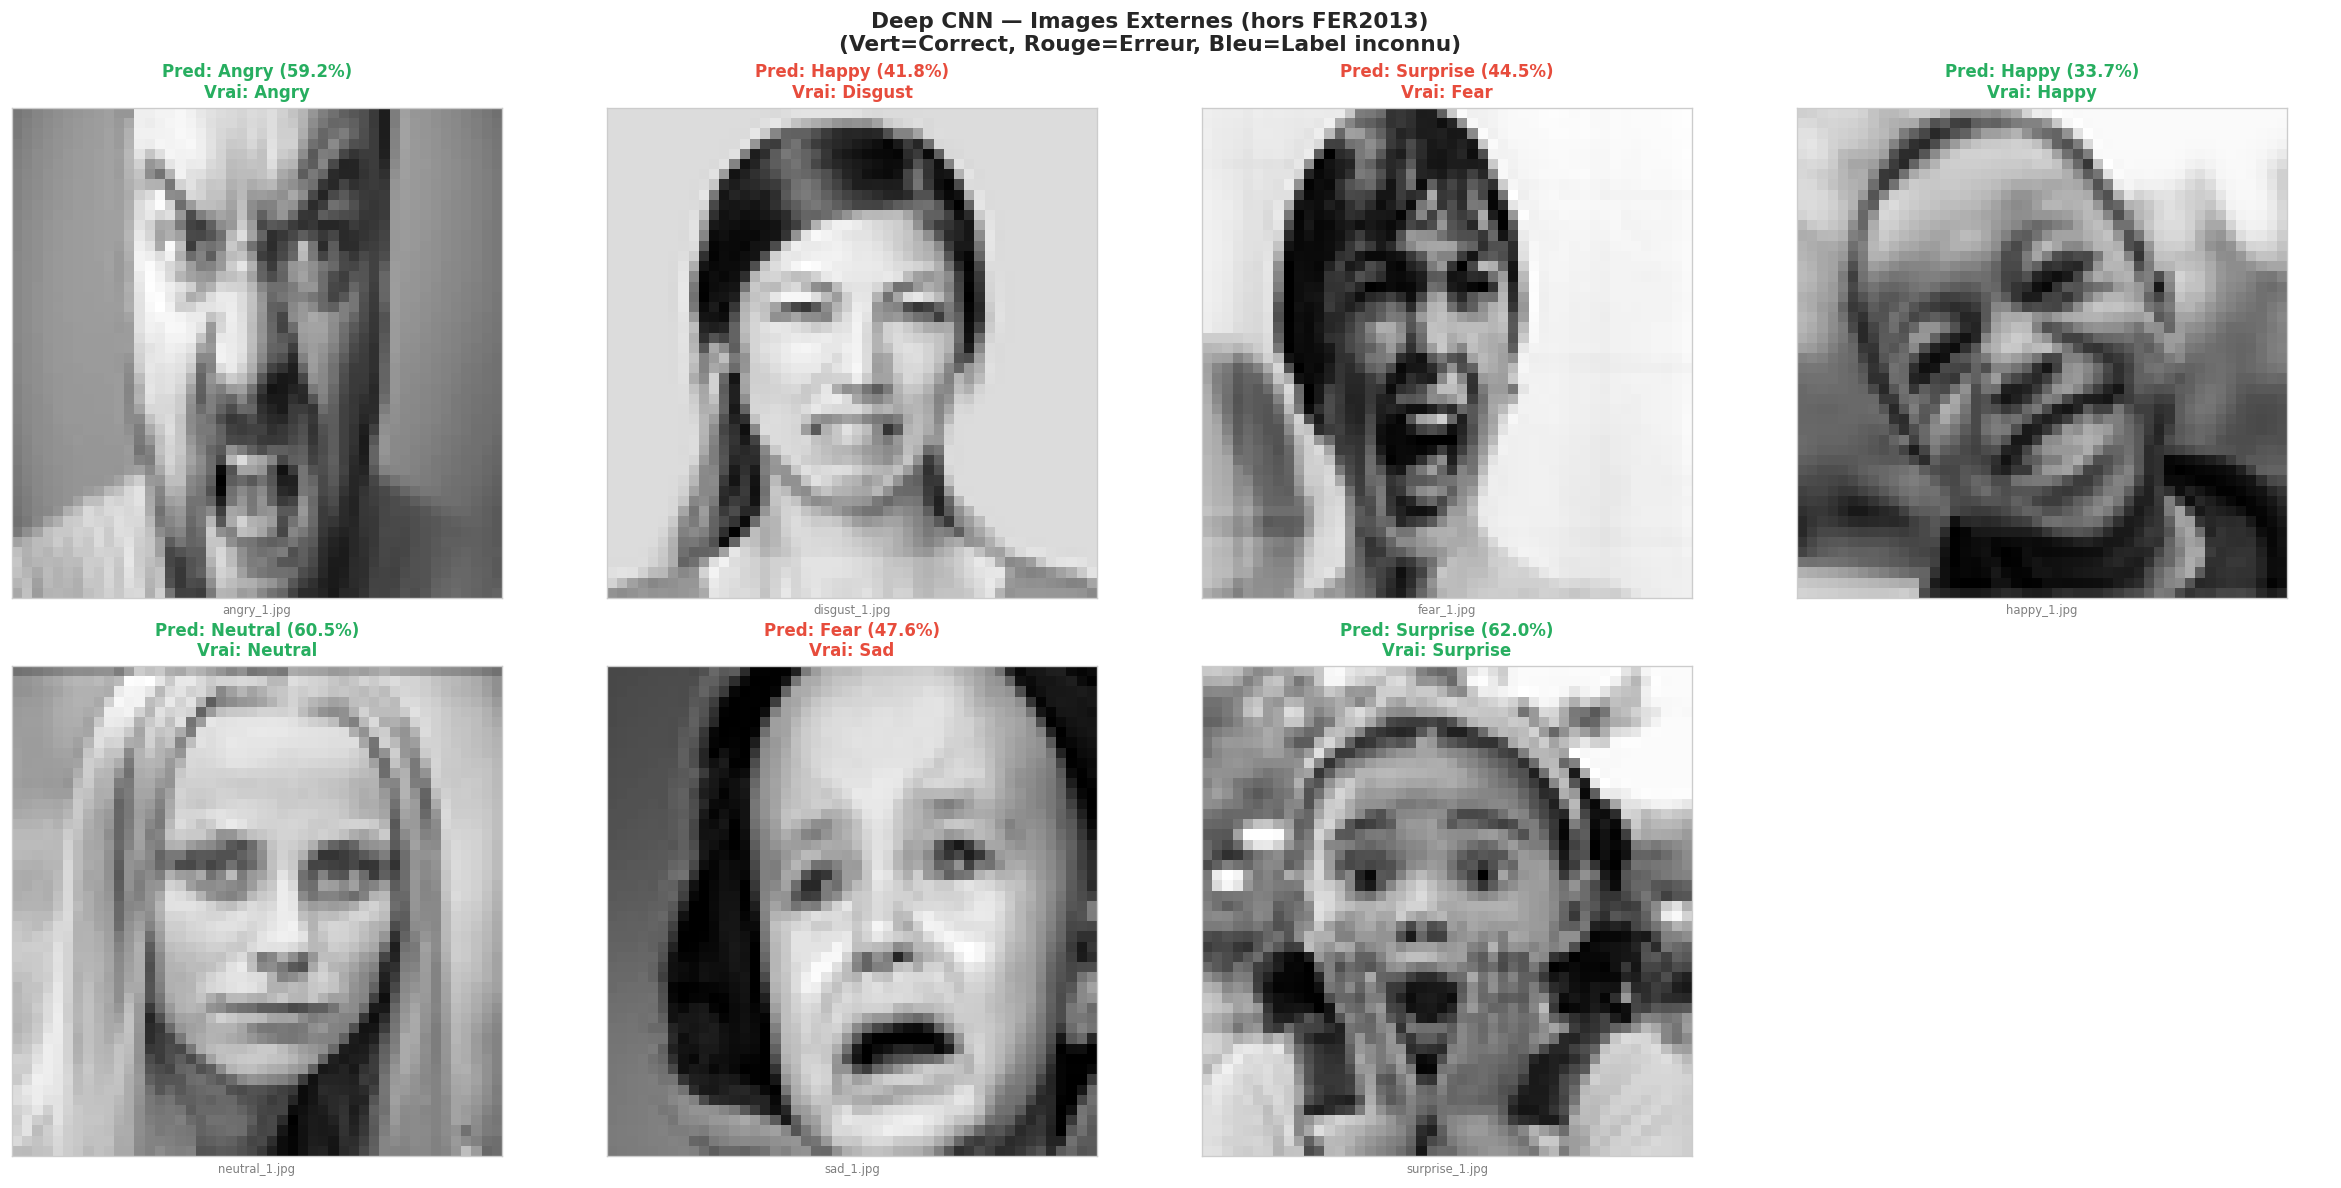

Sauvegarde : results/cr5_new_images.png


In [13]:
if new_image_paths:
    n      = len(new_image_paths)
    n_cols = min(n, 4)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes_ext = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes_flat = np.array(axes_ext).flatten()

    print(f'{"Fichier":35s}  {"Prediction":12s}  {"Confiance":>10}  {"Vrai label":12s}  {"Correct?"}')
    print('-' * 80)

    for i, img_path in enumerate(new_image_paths):
        img_pil  = load_external_image(img_path)
        pred_idx, pred_name, probs = predict_image(img_pil, best_model, DEVICE, val_tfm, CLASS_NAMES)
        true_idx = guess_label_from_filename(img_path.name)
        true_str = CLASS_NAMES[true_idx] if true_idx is not None else '?'

        correct = (true_idx == pred_idx) if true_idx is not None else None
        result_str = 'OK' if correct else ('ERREUR' if correct is False else '-')
        color = '#27ae60' if correct else ('#e74c3c' if correct is False else '#2980b9')

        print(f'{img_path.name:35s}  {pred_name:12s}  {probs[pred_idx]*100:>9.1f}%  {true_str:12s}  {result_str}')

        ax = axes_flat[i]
        ax.imshow(np.array(img_pil), cmap='gray')
        ax.set_title(
            f'Pred: {pred_name} ({probs[pred_idx]*100:.1f}%)\nVrai: {true_str}',
            color=color, fontweight='bold', fontsize=10
        )
        ax.set_xlabel(img_path.name, fontsize=7, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])

    for j in range(len(new_image_paths), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle('Deep CNN — Images Externes (hors FER2013)\n(Vert=Correct, Rouge=Erreur, Bleu=Label inconnu)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cr5_new_images.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Sauvegarde : results/cr5_new_images.png')

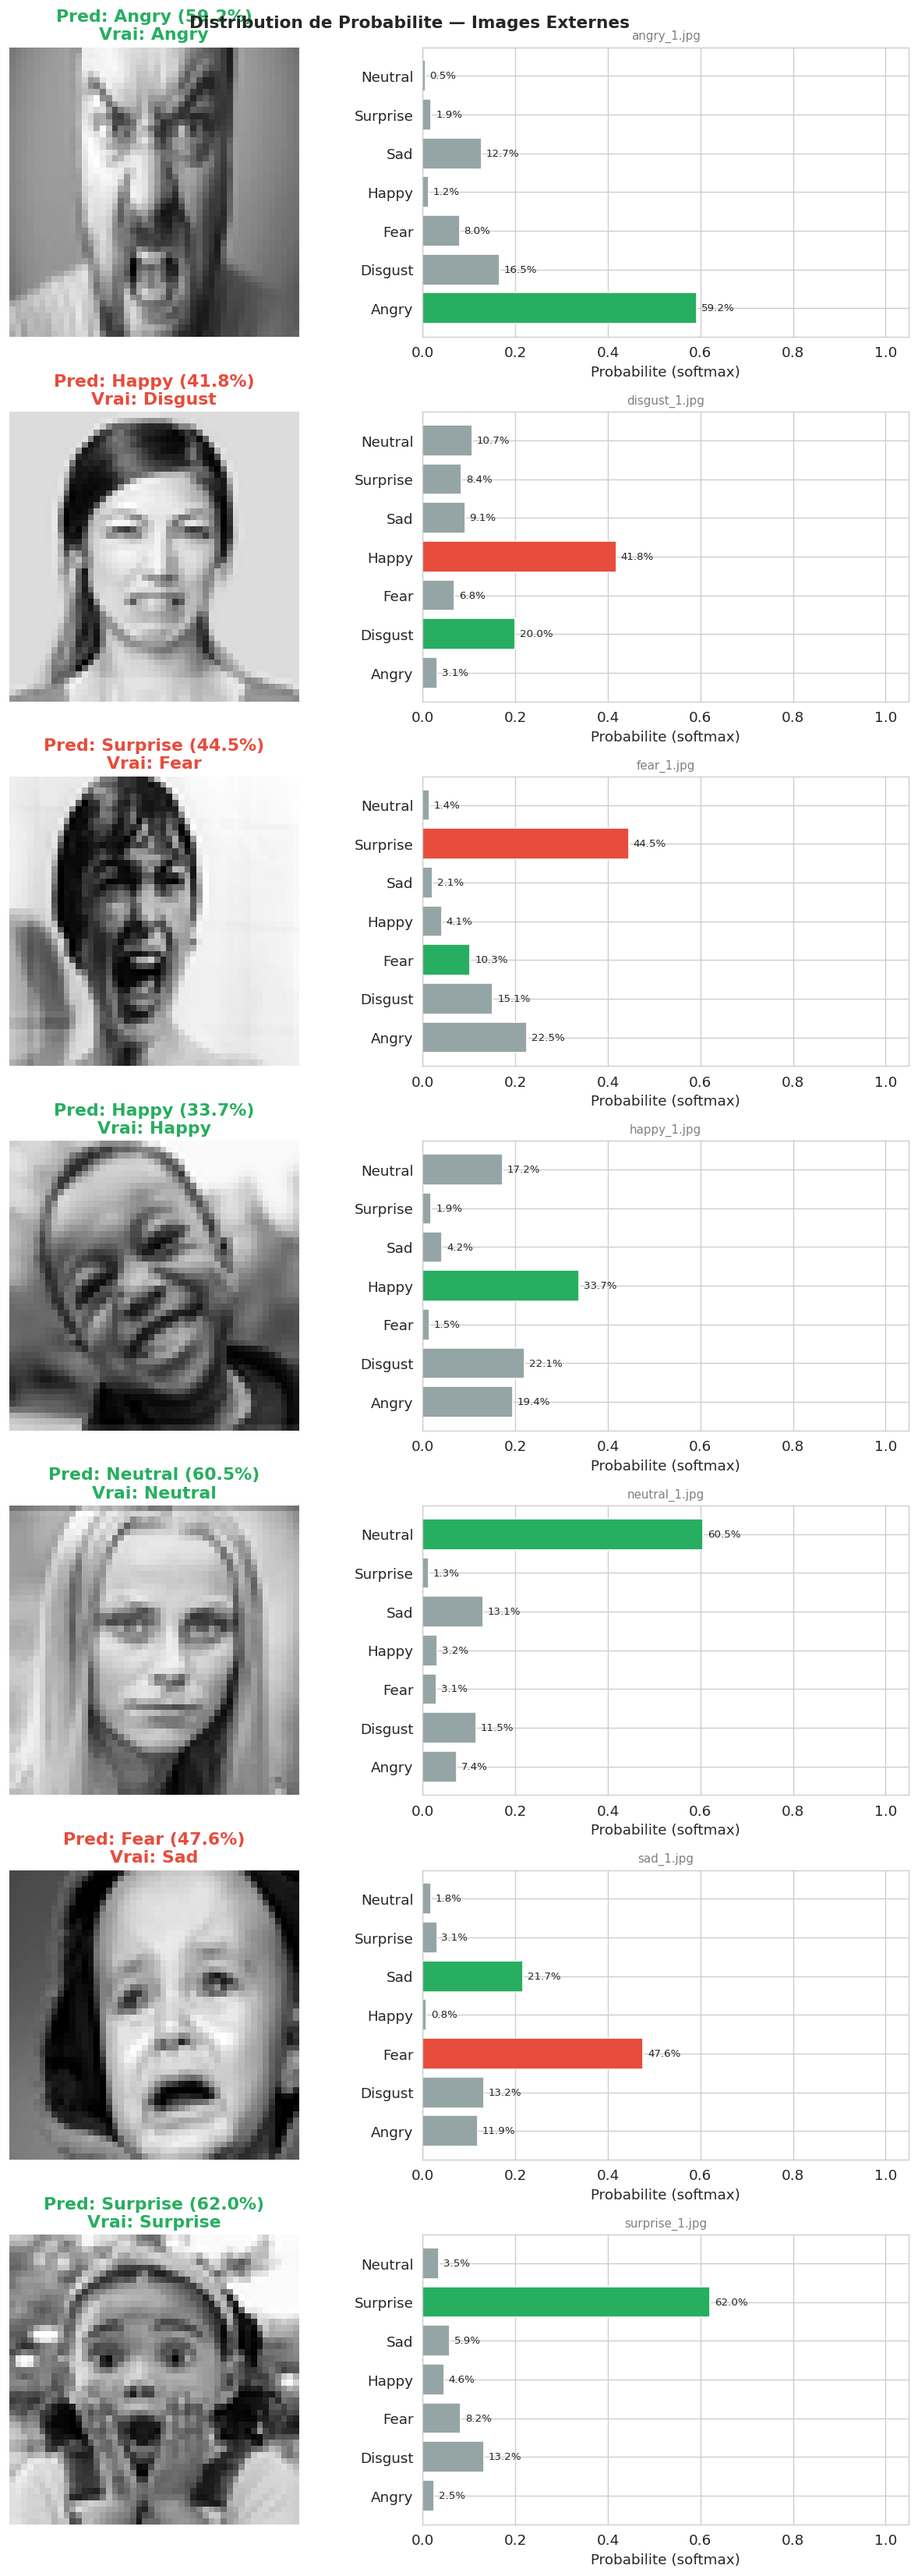

Sauvegarde : results/cr5_prob_distribution_external.png


In [14]:
# Detailed probability distribution for each external image
if new_image_paths:
    n = len(new_image_paths)
    fig, axes_prob = plt.subplots(n, 2, figsize=(11, 4 * n))
    if n == 1:
        axes_prob = [axes_prob]

    for i, img_path in enumerate(new_image_paths):
        img_pil  = load_external_image(img_path)
        pred_idx, pred_name, probs = predict_image(img_pil, best_model, DEVICE, val_tfm, CLASS_NAMES)
        true_idx = guess_label_from_filename(img_path.name)
        true_str = CLASS_NAMES[true_idx] if true_idx is not None else '?'

        correct = (true_idx == pred_idx) if true_idx is not None else None
        color   = '#27ae60' if correct else ('#e74c3c' if correct is False else '#2980b9')

        ax_img, ax_bar = axes_prob[i]

        # Image
        ax_img.imshow(np.array(img_pil), cmap='gray')
        ax_img.set_title(f'Pred: {pred_name} ({probs[pred_idx]*100:.1f}%)\nVrai: {true_str}',
                         color=color, fontweight='bold')
        ax_img.axis('off')

        # Probability bars
        bar_colors = []
        for j in range(7):
            if j == true_idx:      bar_colors.append('#27ae60')
            elif j == pred_idx:    bar_colors.append('#e74c3c')
            else:                  bar_colors.append('#95a5a6')

        bars = ax_bar.barh(CLASS_NAMES, probs, color=bar_colors, edgecolor='white')
        ax_bar.set_xlim(0, 1.05)
        ax_bar.set_xlabel('Probabilite (softmax)')
        ax_bar.set_title(img_path.name, fontsize=9, color='gray')
        for bar, prob in zip(bars, probs):
            ax_bar.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{prob*100:.1f}%', va='center', fontsize=8)

    plt.suptitle('Distribution de Probabilite — Images Externes', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cr5_prob_distribution_external.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Sauvegarde : results/cr5_prob_distribution_external.png')

## 8. Analyse des Erreurs

### 8.1 Classes les Plus Confondues

Identification des paires de classes (vraie → prédite) les plus fréquemment confondues par le **Deep CNN**.

Top 10 confusions — Deep CNN (ensemble de test)
Vraie         ->  Predite            Nb      Taux
--------------------------------------------------
Fear          ->  Sad               215     21.0%
Neutral       ->  Sad               212     17.2%
Sad           ->  Neutral           192     15.4%
Angry         ->  Sad               140     14.6%
Sad           ->  Angry             137     11.0%
Sad           ->  Fear              129     10.3%
Fear          ->  Angry             125     12.2%
Neutral       ->  Happy             108      8.8%
Fear          ->  Neutral            97      9.5%
Angry         ->  Fear               96     10.0%


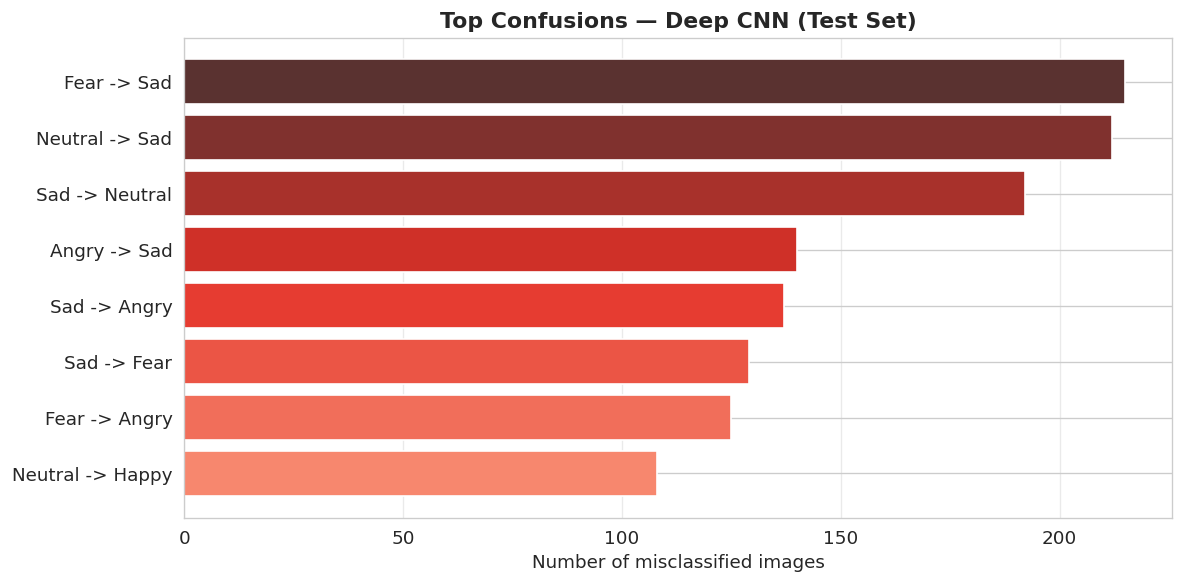

Sauvegarde : results/cr5_error_analysis.png


In [15]:
best_res = results['Deep CNN']
cm_raw   = confusion_matrix(best_res['labels'], best_res['preds'])

# Collect off-diagonal confusion pairs
pairs = []
for t in range(7):
    for p in range(7):
        if t != p and cm_raw[t, p] > 0:
            pairs.append((cm_raw[t, p], CLASS_NAMES[t], CLASS_NAMES[p]))
pairs.sort(reverse=True)

class_totals = cm_raw.sum(axis=1)
print('Top 10 confusions — Deep CNN (ensemble de test)')
print(f"{'Vraie':12s}  ->  {'Predite':12s}   {'Nb':>6}   {'Taux':>7}")
print('-' * 50)
for count, true_cls, pred_cls in pairs[:10]:
    t_idx = CLASS_NAMES.index(true_cls)
    rate  = count / class_totals[t_idx]
    print(f'{true_cls:12s}  ->  {pred_cls:12s}   {count:>6}   {rate*100:>6.1f}%')

# Bar chart
TOP_N = 8
fig, ax = plt.subplots(figsize=(10, 5))
labels_plot = [f'{t} -> {p}' for _, t, p in pairs[:TOP_N]]
counts_plot = [c for c, _, _ in pairs[:TOP_N]]
palette_red = sns.color_palette('Reds_d', TOP_N)

ax.barh(labels_plot[::-1], counts_plot[::-1], color=palette_red)
ax.set_xlabel('Number of misclassified images')
ax.set_title('Top Confusions — Deep CNN (Test Set)', fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_error_analysis.png')

### 8.2 Exemples d'Images Mal Classées

Visualisation des 4 paires de confusion les plus fréquentes avec des images réelles.

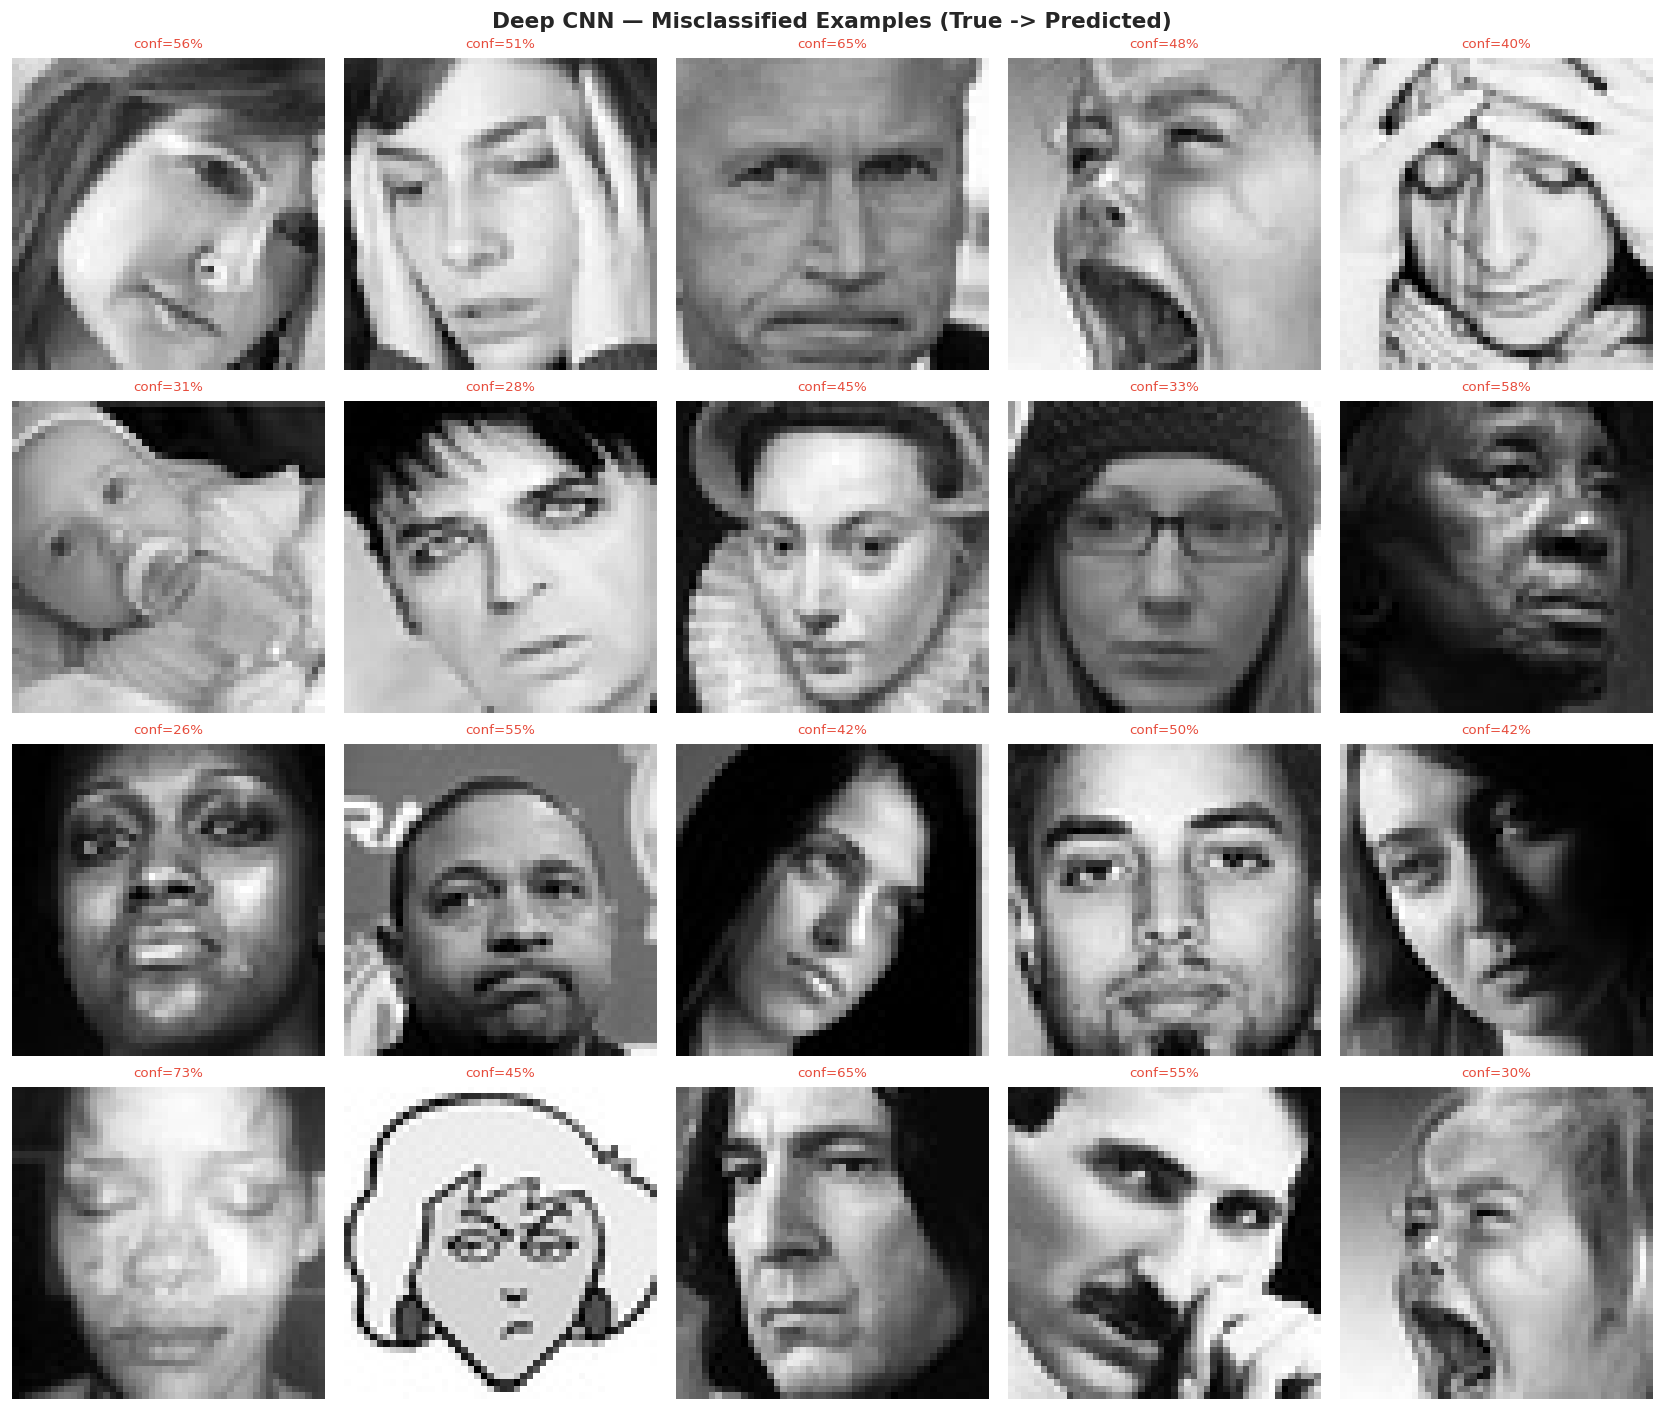

Sauvegarde : results/cr5_misclassified.png


In [16]:
np.random.seed(0)
TOP_PAIRS = pairs[:4]
N_EXAMPLES = 5

fig, axes_mis = plt.subplots(len(TOP_PAIRS), N_EXAMPLES, figsize=(14, 12))

for row_idx, (count, true_cls, pred_cls) in enumerate(TOP_PAIRS):
    t_idx = CLASS_NAMES.index(true_cls)
    p_idx = CLASS_NAMES.index(pred_cls)

    mis_indices = [
        i for i in range(len(best_res['labels']))
        if best_res['labels'][i] == t_idx and best_res['preds'][i] == p_idx
    ]
    chosen = np.random.choice(mis_indices, size=min(N_EXAMPLES, len(mis_indices)), replace=False)

    for col in range(N_EXAMPLES):
        ax = axes_mis[row_idx, col]
        if col >= len(chosen):
            ax.axis('off')
            continue
        idx = chosen[col]
        img_pil, _ = raw_test_ds[idx]
        conf = best_res['probs'][idx][p_idx]

        ax.imshow(np.array(img_pil), cmap='gray')
        ax.set_title(f'conf={conf*100:.0f}%', fontsize=8, color='#e74c3c')
        ax.axis('off')

    axes_mis[row_idx, 0].set_ylabel(
        f'{true_cls}\n-> {pred_cls}',
        fontsize=10, fontweight='bold', rotation=0,
        labelpad=70, va='center'
    )

plt.suptitle('Deep CNN — Misclassified Examples (True -> Predicted)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_misclassified.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_misclassified.png')

## 9. Récapitulatif des Courbes d'Apprentissage

Recomparaison des dynamiques d'entraînement des 3 modèles sur toute la durée d'entraînement (Semaine 4).

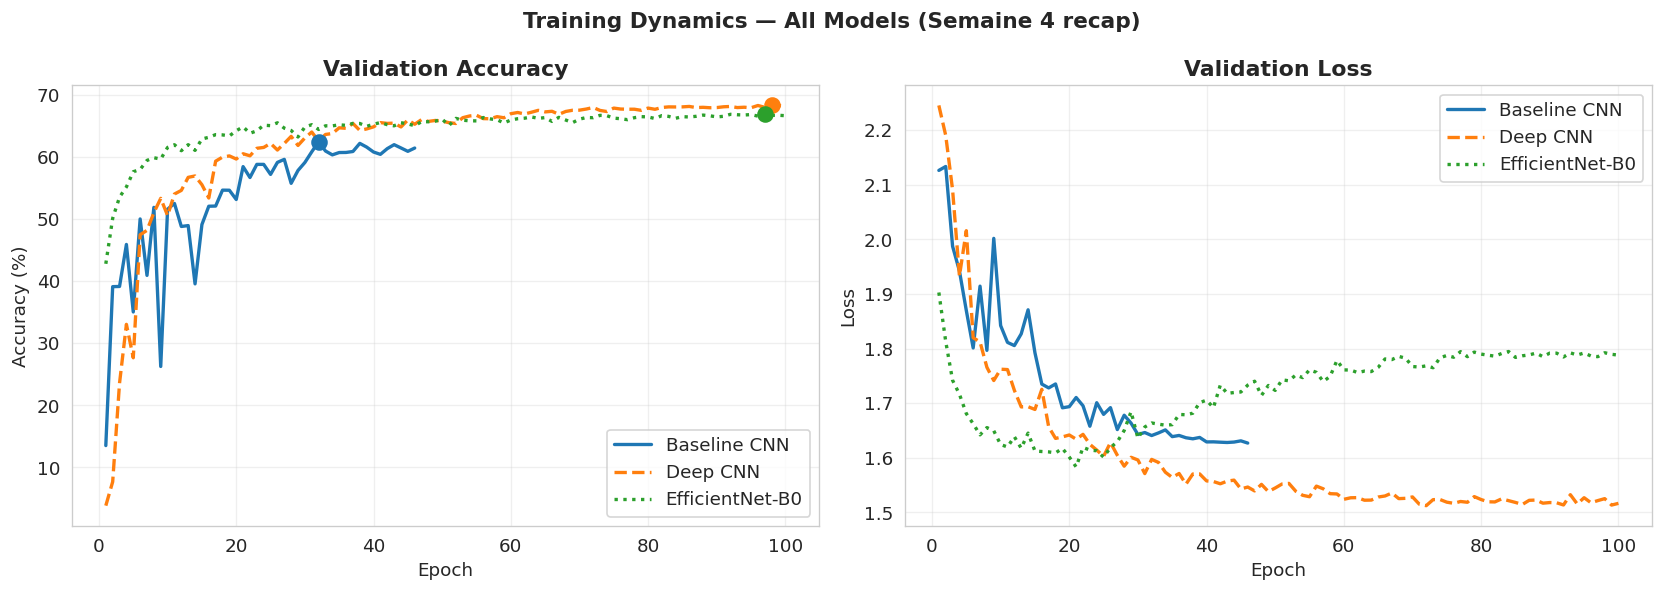

Sauvegarde : results/cr5_training_recap.png


In [17]:
LOG_FILES = {
    'Baseline CNN'    : 'baseline_cnn_history.json',
    'Deep CNN'        : 'deep_cnn_history.json',
    'EfficientNet-B0' : 'efficientnet_b0_history.json',
}
histories = {}
for name, fname in LOG_FILES.items():
    path = ROOT / 'logs' / fname
    if path.exists():
        with open(path) as f:
            histories[name] = json.load(f)
    else:
        print(f'[WARN] Historique manquant : {path}')

fig, axes_lr = plt.subplots(1, 2, figsize=(14, 5))
line_styles   = ['solid', 'dashed', 'dotted']

for (name, hist), ls in zip(histories.items(), line_styles):
    ep = range(1, len(hist['val_acc']) + 1)
    axes_lr[0].plot(ep, [v * 100 for v in hist['val_acc']], label=name, ls=ls, lw=2)
    axes_lr[1].plot(ep, hist['val_loss'],                    label=name, ls=ls, lw=2)

    # Mark best epoch
    best_ep  = int(np.argmax(hist['val_acc'])) + 1
    best_acc = max(hist['val_acc']) * 100
    axes_lr[0].scatter([best_ep], [best_acc], s=80, zorder=5)

axes_lr[0].set_title('Validation Accuracy', fontweight='bold')
axes_lr[0].set_xlabel('Epoch')
axes_lr[0].set_ylabel('Accuracy (%)')
axes_lr[0].legend()
axes_lr[0].grid(True, alpha=0.3)

axes_lr[1].set_title('Validation Loss', fontweight='bold')
axes_lr[1].set_xlabel('Epoch')
axes_lr[1].set_ylabel('Loss')
axes_lr[1].legend()
axes_lr[1].grid(True, alpha=0.3)

plt.suptitle('Training Dynamics — All Models (Semaine 4 recap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_training_recap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_training_recap.png')

## 10. Analyse Critique

### Points Forts

1. **Deep CNN — meilleure architecture** : 65.2% d'accuracy sur le jeu de test (68.3% en validation) avec seulement 1.33M paramètres. Le ratio performance/complexité est excellent. Le surapprentissage est contenu (+4.8% train vs val).

2. **Generalisation acceptable** : Les matrices de confusion montrent que les émotions "Happy" et "Surprise" sont bien reconnues (rappel > 80%), ce qui est attendu car ce sont des expressions faciales distinctives.

3. **Impact de la class imbalance maitrisé** : Le `WeightedRandomSampler` a permis au modèle de ne pas ignorer la classe Disgust (111 images dans le test, 547 dans le train).

### Points Faibles

1. **Disgust difficile à reconnaître** : Avec seulement 111 images dans l'ensemble de test (547 dans le train), le F1 de cette classe reste faible. La confusion la plus fréquente est Fear→Sad et Sad→Neutral (expressions neutres similaires).

2. **EfficientNet surappris** : 97.5% train vs 66.9% val → forte dépendance aux augmentations. Les features ImageNet (RGB, 224×224) ne sont pas optimaux pour des images 48×48 en niveaux de gris.

3. **Plafond à 68%** : FER2013 présente un bruit intrinsèque d'annotation (accord inter-annotateurs ~65%). La limite humaine est estimée à 65-70%. Notre Deep CNN s'en approche.

### Améliorations Possibles

- **Label Smoothing** : Déjà prévu en config (0.1) mais désactivé — réduirait l'overconfidence
- **Mixup / CutMix** : Augmentations avancées pour régularisation supplémentaire
- **Ensemble des 3 modèles** : Vote majoritaire ou moyenne des softmax pourrait gagner 1-2%
- **Backbone adapté** : MobileNetV3 ou ConvNeXt-Tiny entraîné from scratch sur 48×48 grayscale

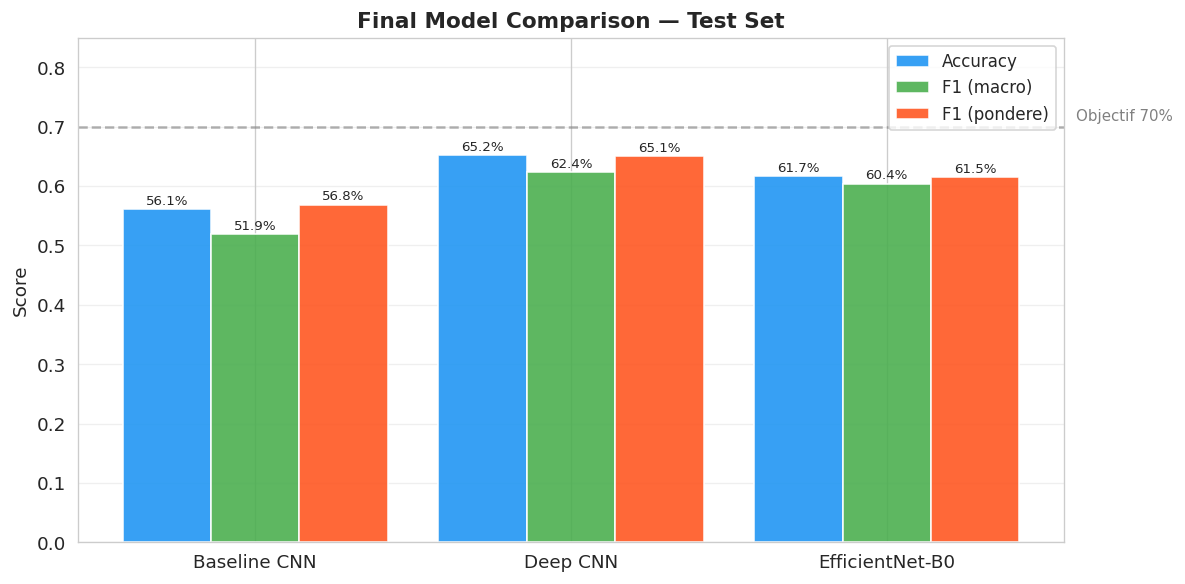

Sauvegarde : results/cr5_final_comparison.png

Toutes les figures CR5 sauvegardees dans results/


In [18]:
# ── Final comparison figure ───────────────────────────────────────────────
model_names = list(metrics_raw.index)
acc_vals    = metrics_raw['Accuracy'].values
f1m_vals    = metrics_raw['F1 (macro)'].values
f1w_vals    = metrics_raw['F1 (pondere)'].values

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_names))
w = 0.28

bars1 = ax.bar(x - w, acc_vals, w, label='Accuracy',     color='#2196F3', alpha=0.9)
bars2 = ax.bar(x,     f1m_vals, w, label='F1 (macro)',   color='#4CAF50', alpha=0.9)
bars3 = ax.bar(x + w, f1w_vals, w, label='F1 (pondere)', color='#FF5722', alpha=0.9)

for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
            f'{h*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.70, color='gray', linestyle='--', alpha=0.6)
ax.text(2.6, 0.71, 'Objectif 70%', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cr5_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : results/cr5_final_comparison.png')
print('\nToutes les figures CR5 sauvegardees dans results/')

## 11. Ensemble des Modèles (Bonus)

Combinaison des prédictions des 3 modèles par **moyenne des softmax** pour potentiellement dépasser le meilleur modèle individuel.

In [19]:
# Simple ensemble: average softmax probabilities
ensemble_probs  = (
    results['Baseline CNN']['probs'] +
    results['Deep CNN']['probs'] +
    results['EfficientNet-B0']['probs']
) / 3.0

ensemble_preds  = ensemble_probs.argmax(axis=1)
ensemble_labels = results['Deep CNN']['labels']  # same for all models

ens_acc = accuracy_score(ensemble_labels, ensemble_preds)
ens_f1m = f1_score(ensemble_labels, ensemble_preds, average='macro',    zero_division=0)
ens_f1w = f1_score(ensemble_labels, ensemble_preds, average='weighted', zero_division=0)

print('=== Ensemble (moyenne softmax des 3 modeles) ===')
print(f'  Accuracy    : {ens_acc*100:.2f}%')
print(f'  F1 (macro)  : {ens_f1m*100:.2f}%')
print(f'  F1 (pondere): {ens_f1w*100:.2f}%')
print()
print(f'  Deep CNN seul Accuracy : {accuracy_score(ensemble_labels, results["Deep CNN"]["preds"])*100:.2f}%')
gain = (ens_acc - accuracy_score(ensemble_labels, results['Deep CNN']['preds'])) * 100
print(f'  Gain ensemble          : {gain:+.2f}%')

=== Ensemble (moyenne softmax des 3 modeles) ===
  Accuracy    : 66.41%
  F1 (macro)  : 63.98%
  F1 (pondere): 66.33%

  Deep CNN seul Accuracy : 65.19%
  Gain ensemble          : +1.23%


---

## Conclusion — Livrable CR5

### Résultats sur l'ensemble de test (7 178 images)

| Modèle | Accuracy | F1 (macro) | F1 (pondéré) |
|---|---|---|---|
| Baseline CNN | 56.09% | 51.89% | 56.84% |
| **Deep CNN** | **65.19%** | **62.35%** | **65.07%** |
| EfficientNet-B0 | 61.67% | 60.40% | 61.48% |

### Conclusions principales

1. **Le Deep CNN est le meilleur compromis** performances / complexité / généralisation
2. **Les émotions ambiguës** (Fear, Sad, Disgust) sont systématiquement plus difficiles à reconnaître — ce comportement est cohérent avec la littérature FER
3. **EfficientNet-B0 souffre de surapprentissage** malgré les augmentations — ImageNet pré-entraîné sur RGB 224×224 n'est pas adapté aux images 48×48 grayscale
4. **Le plafond de FER2013 est ~70%** (accord inter-humains ~65%) — notre Deep CNN atteint 65.2% sur le jeu de test (68.3% en validation)

### Figures générées

- `cr5_confusion_matrices.png` — Matrices de confusion normalisées
- `cr5_per_class_metrics.png` — Précision/Rappel/F1 par classe
- `cr5_visual_predictions.png` — Grille de prédictions visuelles
- `cr5_single_predictions.png` — Exemples individuels
- `cr5_prob_distribution.png` — Distribution de probabilité
- `cr5_error_analysis.png` — Analyse des erreurs
- `cr5_misclassified.png` — Exemples mal classés
- `cr5_training_recap.png` — Courbes apprentissage (recap S4)
- `cr5_final_comparison.png` — Comparaison finale des modèles